In [25]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import GoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv(dotenv_path="../.env")



True

In [26]:
class LLmState(TypedDict):
    question: str
    answer: str

In [27]:
def llm_qa(state: LLmState)-> LLmState:
    prompt= f"Answer the following question: {state['question']}"
    model= GoogleGenerativeAI(model='gemini-3-flash-preview')
    response= model.invoke(prompt)
    print(type(response))
    state['answer']= response
    return state

In [28]:
graph= StateGraph(LLmState)

graph.add_node('llm_qa', llm_qa)

graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

workflow= graph.compile()

In [29]:
initial_state={'question': "what is langgraph?"}
final_state= workflow.invoke(initial_state)

print(final_state) 

<class 'str'>
{'question': 'what is langgraph?', 'answer': '**LangGraph** is a library developed by the LangChain team designed to build complex, stateful, and multi-agent applications using Large Language Models (LLMs).\n\nWhile standard LangChain is great for creating "chains" of actions (sequences that go from A to B to C), LangGraph is designed for **circular logic (loops)** and **fine-grained control over state.**\n\nHere is a breakdown of what makes LangGraph unique and why it is used:\n\n---\n\n### 1. The Core Concept: Graphs vs. Chains\nIn a traditional LLM "chain," the flow is linear (a Directed Acyclic Graph or DAG). You provide an input, it passes through a few steps, and you get an output.\n\nHowever, real-world agents often need to:\n*   **Loop:** Try a task, check the result, and if it\'s wrong, go back and try again.\n*   **Maintain State:** Keep track of a complex "memory" of what has happened across many turns.\n*   **Collaborate:** Have multiple specialized agents tal

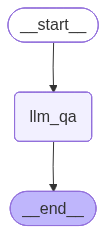

In [30]:
graph.compile()